<div align='center'>
<h1>Laboratorio 2: Imágenes 📷</h1>
</div>

<div align='center'>
<strong>MDS7202: Laboratorio de Programación Científica para Ciencia de Datos</strong>
</div>

---

### Cuerpo Docente

- Profesores: Pablo Badilla y Diego Cortez
- Auxiliares: Valentina Rojas y Melanie Peña
- Ayudantes: Javiera Arévalo, Tamara Carrasco y Ignacio Reyes


### Equipo: SUPER IMPORTANTE - notebooks sin nombre no serán revisados

- Nombre de alumno 1: Álvaro Sifuentes Tasayco
- Nombre de alumno 2: Sebastián Morales Castillo


---

### Reglas

- **Grupos de 2 personas**
- Cualquier duda fuera del horario de clases al foro. Mensajes al equipo docente serán respondidos por este medio.
- Prohibido copiar.
- Uso de LLM (Copilot, Claude, Antigravity, Cursor, etc.) restringido a consultas, documentación y corrección de errores. 

### Temas a tratar:

- Programación Orientada a Objetos.
- Programación Funcional.
- `Numpy` para manejo de datos en arreglos/tensores.




### Objetivos principales del laboratorio

- Aplicar los paradigmas y buenas prácticas de programación vistas hasta este momento.
- Comprender y aprovechar las ventajas que nos ofrece la librería `numpy` con respecto a trabajar en Python 'puro'.
- Visualizar aplicaciones de filtros de imágenes sin el uso de librerías.
- Verificar que el uso indiscriminado de `for` puede afectar la eficiencia al procesar datos masivos.




El laboratorio deberá ser desarrollado **sin el uso indiscriminado de iteradores nativos de Python (aka `for`, `while`)**. La idea es que aprendan a exprimir al máximo las funciones optimizadas que nos entrega `numpy`, las cuales (vale mencionar), son mucho más eficientes que los iteradores nativos sobre arreglos.

El lab estará basado en algunos conceptos básicos de procesamiento de imágenes, por lo que te iremos guiando, paso a paso por cada uno de los tópicos a desarrollar.

## Descripción del laboratorio

En Data Science son múltiples las aplicaciones que exigen el uso exhaustivo de listas de varias dimensiones. Estas entidad reciben formalmente el nombre de **arreglos o tensores**.

Pensemos en que queremos almacenar objetos en un casillero común y corriente: podemos pensar que este puede ser representado por una matriz de dos dimensiones: alto y ancho. ¿Qué sucederá si este casillero nos queda pequeño y queremos guardar más información del mismo tipo?: La solución simple es agregar otro casillero. Esto puede ser pensado como el aumento de la dimensión de nuestro objeto, pasando a ser ahora (alto, ancho, id casillero). Esto no es otra cosa que un **tensor de 3 dimensiones**.

<br>
<center>
<img src="https://raw.githubusercontent.com/MDS7202/MDS7202/refs/heads/main/recursos/2026-01/labs/lab2/lockers.png" width=600 />
</center>
<br>

### ¿Bueno y que tiene que ver todo esto con las imágenes?

Una imagen es una representación visual de una matriz que contiene números que describen intensidades de color (llamados píxeles). 

Esto, visto desde la perspectiva de una imagen en blanco y negro, sería una matriz que contiene las diferentes intensidades de los píxeles desde 0 a 255.

<br>
<center>
    <img src="https://raw.githubusercontent.com/MDS7202/MDS7202/refs/heads/main/recursos/2026-01/labs/lab2/rep_img.png" width=800 alt="Representación de una imagen" />
</center>
<br>

Cuando las imágenes poseen colores, las imágenes son, de hecho, una bella representación de lo que es un tensor: estas pueden ser representadas por un tensor de 3 dimensiones que les dan el *ancho, alto y el canal*, en donde son alojados los colores de la imagen.

<br>
<center>
<img src="https://raw.githubusercontent.com/MDS7202/MDS7202/refs/heads/main/recursos/2026-01/labs/lab2/channels.png" width=600 alt="Representación de una imagen" />
</center>
<br>

Como pueden ver, la imagen puede ser interpretada como un tensor de tres dimensiones (un ancho, un alto y la intensidad de cada color) en el que a cada posición $(i,j)$ de la imagen, le asociaremos 3 intensidades de colores RGB (Rojo, Verde y Azul). Estas intensidades irán desde el $0$ al $255$. La combinación de estos 3 canales nos permitirá representar gran parte de los colores que encontramos en la naturaleza.

**Instalar paquetes**


En una consola, ejecutar:


```bash
uv add matplotlib pillow plotly
```

In [41]:
# En este lab usaremos adicionalmente pillow (PIL), una estupenda librería
# para manejar imágenes.
# https://pillow.readthedocs.io/en/stable/

import numpy as np
import plotly.express as px
from PIL import Image

foto = np.array(Image.open("./images_lab/cobija.PNG").convert("RGB"))

# Solo para ejemplificar, usaremos plotly
# NO SE DEBE USAR EN EL RESTO DEL LAB, SOLO AQUÍ

fig = px.imshow(foto)
fig.show()

A continuación, imprimimos el número de dimensiones y la forma del arreglo que representa la imagen.

In [42]:
print(f"Número de dimensiones: {foto.ndim}")
print(f"Número de elementos por dimensión: {foto.shape}")

Número de dimensiones: 3
Número de elementos por dimensión: (470, 597, 3)


Finalmente visualizamos de forma aleatoria los pixeles de cada canal para mostrar sus intensidades.

In [43]:
print(f"Ejemplo de pixel (10, 200) en el canal 0 - Red: {foto[10, 200, 0]}")
print(f"Ejemplo de pixel (10, 200) en el canal 1- Green: {foto[10, 200, 1]}")
print(f"Ejemplo de pixel (10, 200) en el canal 2- Blue: {foto[10, 200, 2]}")

Ejemplo de pixel (10, 200) en el canal 0 - Red: 97
Ejemplo de pixel (10, 200) en el canal 1- Green: 70
Ejemplo de pixel (10, 200) en el canal 2- Blue: 48


Con lo anterior, suponiendo que la imagen del "gatito" tiene una altura igual a 600 y un ancho de 400, el tensor $G$ que representa a la imagen vendrá dado por $G[600, 400, 3]$. 

### ¿Ya, pero esto tiene aplicaciones más allá de guardar información en casilleros?

Para el caso de imágenes podemos encontrar múltiples aplicaciones con la manipulación de los tensores y operando matemáticamente con ellos. Algunas de las aplicaciones más conocidas (y que aplicaremos) son las siguientes:

- **Obtener el negativo de una imagen**: Consiste en obtener el color complementario de una imagen, para esto debemos restar la imagen con la máxima intensidad que podemos encontrar en una imagen (o sea 255).
    
    
- **Pasar a escala de grises una imagen**: Los valores RGB se convierten a escala de grises mediante la fórmula NTSC: 

    $$ imagen\_gris = 0.299 * Rojo + 0.587 * Verde + 0.114 * Azul $$
    
    Esta fórmula representa la percepción relativa de la persona promedio del brillo de la luz roja, verde y azul.
    
    
- **Mejora de saturación**: Permite intensificar o reducir los colores de una imagen. Se calcula primero la luminancia de la imagen (escala de grises) y luego se escala la diferencia entre la imagen original y esa luminancia mediante un factor $F$:

    $$ R = imagen\_gris + F * (img - imagen\_gris) $$
    
    Con $F > 1$ se aumenta la saturación, $F < 1$ se reduce y $F = 0$ produce una imagen en escala de grises.


- **Mejora de contraste**: Son múltiples las técnicas que nos permiten mejorar el contraste de una imagen, pero, una técnica simple para modificar los contrastes consta en obtener un factor de corrección llamado F en base al contraste deseado (C). Luego, es aplicado en la diferencia entre la imagen y 128. De esta forma obtenemos R, que es la imagen con la mejora de contraste deseada.

    $$ F=259*(C+255)/(255*(259-C)) $$
    $$ R=F*(img-128)+128 $$
  
  
- **Convolución**: Consiste en recorrer una imagen por cada uno de sus canales utilizando una matriz que lleva por nombre Kernel. El kernel, examinará los conjuntos de pixeles que recorre, aplicando una multiplicación de los valores circundantes ,y sumando todos los valores generados de este producto para generar un nuevo pixel en el tensor de salida.

<div style="text-align: center;">
    <img src="https://raw.githubusercontent.com/MDS7202/MDS7202/refs/heads/main/recursos/2026-01/labs/lab2/conv.gif" alt="Animación de convolución">
<div style="text-align: center;">

---

# Desarrollo

En base a lo explicado y visto en clases, a continuación, deben construir cada uno de los programas solicitados en las actividades señaladas más abajo. Estas, deben ser desarrolladas de forma grupal (**2 personas por grupo**) y, la solución no debe ser compartida con personas externas al grupo; si se detecta que dos grupos entregan el mismo trabajo, será considerado plagio y se tomarán medidas al respecto.

## 2. Creación de Clases y Funciones

#### Importamos librerías útiles 😸

In [44]:
from pathlib import Path
from typing import Union

import matplotlib.pyplot as plt

# Librerías cores del lab.
import numpy as np
from PIL import Image
from scipy.signal import convolve2d

### 2.1. Carga de imágenes y visualización

### Carga de imágenes en diccionarios

Las siguientes celdas de código les permitirán cargar las imágenes que utilizaremos durante este laboratorio.



In [45]:
def load_image(path):
    ruta = Path(path)
    image = np.array(Image.open(ruta), dtype="int")
    return image


images = {
    "gatitos": [
        load_image("./images_lab/gato1.jpg"),
        load_image("./images_lab/gato2.jpg"),
        load_image("./images_lab/gato4.jpg"),
    ],
}

### Plot de imágenes

A continuación, usaremos la función `def show(imagen)` (definida más abajo) para explorar las imágenes cargadas en la celda anterior.

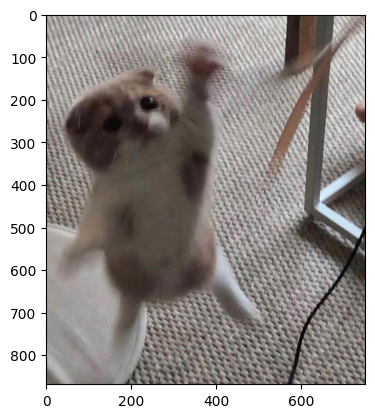

In [46]:
def show(imagen):
    plt.imshow(imagen)
    plt.show()
    x, y, z = imagen.shape


show(images["gatitos"][0])

### 2.2 Clase imágenes [3 puntos]

Ahora que sabemos cómo cargar y mostrar una imagen, cree una clase llamada "`Imagen`" la que cumpla las siguientes características:

- Un constructor que tome como argumento una imagen y que la guarde como atributo. `__init__` debe comprobar que la imagen es un arreglo de numpy (con `isinstance`) y adicionalmente que este tiene 3 dimensiones (**ya implementado como ejemplo**).

- El método `show()` que muestre la imagen usando imshow de `Matplotlib`. [0.2]
- El método `__repr__()` que retorna un string conteniendo información básica de la imagen: dimensiones, tipo de datos, peso y estadísticas del arreglo: min, max, mean, std, p25, p50, p75 (ver docstring para el formato). Si los valores son número flotantes, deben estar redondeados a la centésima. [1 punto]
- Sobrecarga de los métodos mágicos `__add__`, `__sub__` y `__mul__` (y sus operaciones conmutativas `__radd__`, `__rsub__` y `__rmul__`) para realizar operaciones matemáticas entre el objeto y valores de tipo `int`, `float`, `np.ndarray` u otro objeto `Imagen`. Reglas específicas de este punto: 
  - Realice la función pensando que la operación se puede aplicar tanto por izquierda como por derecha (es decir, tanto `imagen + 10` como `10 + imagen`). 
  - Como estamos trabajando con imágenes en rango (0,255), los outputs deben ser enteros. Por ende, utilice `.astype(int)` para transformar los arrays de salida a un formato legible por matplotlib.
  - **Importante**: las operaciones deben implementar **saturación** de imágenes. Es decir, la suma o resta deben dar como valor máximo 255 y/o como valor mínimo 0 respectivamente.
  - Cuando la operación se realiza entre dos objetos `Imagen`, las dimensiones de ambas imágenes **deben coincidir exactamente**. Si no coinciden, deben lanzar un `ValueError("Las dimensiones de la imagen a operar ({alto_other} x {ancho_other} x {canales_other}) no calzan con las de la imagen original ({alto_self} x {ancho_self} x {canales_self}) ")`. Chequeen esto a través los atributos de numpy.
  - Compruebe que la funcionalidad implementada es la correcta mediante la ejecución de los tests (via `asserts`) incluidos un par de celdas más abajo. Si no pasan los tests, el método será considerado como incorrecto.
  - [0.3] puntos por cada método.

- Notas:

> **⚠️ Indexado condicional obligatorio:** Para implementar la saturación, **deben usar indexado condicional** (similar a los filtros de pandas/numpy). Por ejemplo: `result[result > 255] = 255`. 

> **🧪 Tipos de datos:** Usen siempre `.astype(int)` en el resultado final de cada operación. No usen `uint8`, ya que ese tipo desborda silenciosamente (por ejemplo, `uint8(200) + 100 = 44` en lugar de `255`), mientras que `int` permite detectar estos valores y saturar correctamente con indexado condicional.

> **📌 Inmutabilidad:** La idea es que la imagen contenida en la clase sea **inmutable**. Por esto, **todos los métodos que modifiquen la imagen deben retornar un nuevo objeto `Imagen`** que contenga la imagen modificada como una **copia** (`np.copy()`). Nunca modifiquen `self.imagen` directamente, ya que eso mutaría el objeto original, lo que puede producir bugs difíciles de detectar.

> - Pueden reutilizar el código implementado en las celdas anteriores para implementar los métodos `show` y `__repr__`. Sin embargo, **no invoquen directamente esas funciones**.



In [47]:
class Imagen:
    """Contenedor de imágenes."""

    def __init__(self, img: np.ndarray) -> None:
        if isinstance(img, np.ndarray):
            if img.ndim != 3:
                raise ValueError("El argumento debe ser un arreglo de numpy de solo 3 dimensiones")
            if img.shape[-1] != 3:
                raise ValueError(
                    "El argumento debe ser un arreglo de numpy de solo 3 dimensiones "
                    "tal que la última dimensión solo tiene 3 canales"
                )
            self.imagen = img
        else:
            raise TypeError("Debes entregar un arreglo de numpy como argumento del constructor de Imagen")

    def show(self) -> None:
        """Muestra la imágen contenida en el objeto utilizando imshow de Matplotlib."""
        plt.imshow(self.imagen)
        plt.show()

    def __repr__(self) -> str:
        """Retorna un string con las características de la imagen cargada."""
        img = self.imagen
        alto, ancho, canales = img.shape
        peso_mb = img.nbytes / 1e6
        minimos = np.min(img, axis=(0, 1))
        maximos = np.max(img, axis=(0, 1))
        medias = np.mean(img, axis=(0, 1))
        stds = np.std(img, axis=(0, 1))
        p25 = np.percentile(img, 25, axis=(0, 1))
        p50 = np.percentile(img, 50, axis=(0, 1))
        p75 = np.percentile(img, 75, axis=(0, 1))
        return (
            "Características de la imagen cargada:\n"
            f"- Dimensiones: {alto} x {ancho} x {canales}\n"
            f"- Tipo de datos: {img.dtype}\n"
            f"- Peso en MB: {peso_mb:.2f}\n"
            "- Estadísticas por canal:\n"
            f"    - Min: ({int(minimos[0])}, {int(minimos[1])}, {int(minimos[2])})\n"
            f"    - Max: ({int(maximos[0])}, {int(maximos[1])}, {int(maximos[2])})\n"
            f"    - Mean: ({medias[0]:.2f}, {medias[1]:.2f}, {medias[2]:.2f})\n"
            f"    - Std: ({stds[0]:.2f}, {stds[1]:.2f}, {stds[2]:.2f})\n"
            f"    - Percentil 25: ({p25[0]:.2f}, {p25[1]:.2f}, {p25[2]:.2f})\n"
            f"    - Percentil 50: ({p50[0]:.2f}, {p50[1]:.2f}, {p50[2]:.2f})\n"
            f"    - Percentil 75: ({p75[0]:.2f}, {p75[1]:.2f}, {p75[2]:.2f})"
        )

    def __add__(self, other: Union[int, float, np.ndarray, "Imagen"]) -> "Imagen":
        # caso 1: si es otra imagen
        if isinstance(other, Imagen):
            if self.imagen.shape != other.imagen.shape:
                alto_self, ancho_self, canales_self = self.imagen.shape
                alto_other, ancho_other, canales_other = other.imagen.shape
                raise ValueError(
                    f"Las dimensiones de la imagen a operar ({alto_other} x {ancho_other} x {canales_other}) no calzan con las de la imagen original ({alto_self} x {ancho_self} x {canales_self}) "
                )
            resultado = self.imagen + other.imagen
        # caso 2: número o array
        else:
            resultado = self.imagen + other

        # saturación
        resultado = np.copy(resultado)
        resultado[resultado > 255] = 255
        resultado[resultado < 0] = 0
        return Imagen(resultado.astype(int))

    def __radd__(self, other: Union[int, float, np.ndarray, "Imagen"]) -> "Imagen":
        return self.__add__(other)

    def __sub__(self, other: Union[int, float, np.ndarray, "Imagen"]) -> "Imagen":
        if isinstance(other, Imagen):
            if self.imagen.shape != other.imagen.shape:
                raise ValueError("Las imágenes deben tener las mismas dimensiones")
            resultado = self.imagen - other.imagen
        elif isinstance(other, int | float | np.ndarray):
            resultado = self.imagen - other
        else:
            return NotImplemented
        resultado = np.copy(resultado)
        resultado[resultado > 255] = 255
        resultado[resultado < 0] = 0
        return Imagen(resultado.astype(int))

    def __rsub__(self, other: Union[int, float, np.ndarray, "Imagen"]) -> "Imagen":
        # caso 1: otra imagen
        if isinstance(other, Imagen):
            if self.imagen.shape != other.imagen.shape:
                alto_self, ancho_self, canales_self = self.imagen.shape
                alto_other, ancho_other, canales_other = other.imagen.shape
                raise ValueError(
                    f"Las dimensiones de la imagen a operar ({alto_other} x {ancho_other} x {canales_other}) no calzan con las de la imagen original ({alto_self} x {ancho_self} x {canales_self}) "
                )
            resultado = other.imagen - self.imagen
        # caso 2: número o array
        else:
            resultado = other - self.imagen

        # saturación
        resultado = np.copy(resultado)
        resultado[resultado > 255] = 255
        resultado[resultado < 0] = 0
        return Imagen(resultado.astype(int))

    def __mul__(self, other: Union[int, float, np.ndarray, "Imagen"]) -> "Imagen":
        # caso 1: si es otra imagen
        if isinstance(other, Imagen):
            if self.imagen.shape != other.imagen.shape:
                alto_self, ancho_self, canales_self = self.imagen.shape
                alto_other, ancho_other, canales_other = other.imagen.shape
                raise ValueError(
                    f"Las dimensiones de la imagen a operar ({alto_other} x {ancho_other} x {canales_other}) no calzan con las de la imagen original ({alto_self} x {ancho_self} x {canales_self}) "
                )
            resultado = self.imagen * other.imagen
        # caso 2: número o array
        else:
            resultado = self.imagen * other

        # saturación
        resultado = np.copy(resultado)
        resultado[resultado > 255] = 255
        resultado[resultado < 0] = 0
        return Imagen(resultado.astype(int))

    def __rmul__(self, other: Union[int, float, np.ndarray, "Imagen"]) -> "Imagen":
        return self.__mul__(other)

**Scripts para ir probando sus implementaciones**

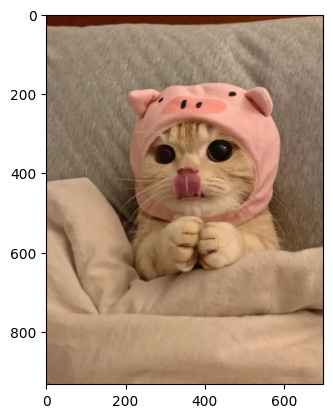

Características de la imagen cargada:
- Dimensiones: 933 x 700 x 3
- Tipo de datos: int64
- Peso en MB: 15.67
- Estadísticas por canal:
    - Min: (5, 0, 0)
    - Max: (255, 229, 221)
    - Mean: (162.93, 130.23, 104.31)
    - Std: (38.83, 35.17, 32.93)
    - Percentil 25: (139.00, 114.00, 91.00)
    - Percentil 50: (165.00, 135.00, 109.00)
    - Percentil 75: (190.00, 155.00, 127.00)

In [48]:
gatito = Imagen(images["gatitos"][1])

gatito.show()
gatito

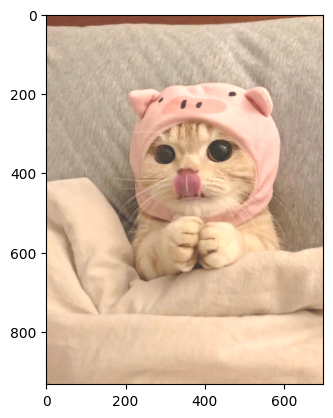

Características de la imagen cargada:
- Dimensiones: 933 x 700 x 3
- Tipo de datos: int64
- Peso en MB: 15.67
- Estadísticas por canal:
    - Min: (55, 50, 50)
    - Max: (255, 255, 255)
    - Mean: (210.85, 180.23, 154.31)
    - Std: (35.62, 35.17, 32.93)
    - Percentil 25: (189.00, 164.00, 141.00)
    - Percentil 50: (215.00, 185.00, 159.00)
    - Percentil 75: (240.00, 205.00, 177.00)

In [49]:
# Prueba: Suma de un escalar a la imagen
gatito_sum = gatito + 50
gatito_sum.show()
gatito_sum

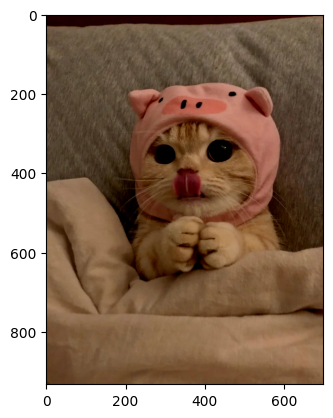

Características de la imagen cargada:
- Dimensiones: 933 x 700 x 3
- Tipo de datos: int64
- Peso en MB: 15.67
- Estadísticas por canal:
    - Min: (0, 0, 0)
    - Max: (205, 179, 171)
    - Mean: (113.12, 81.16, 56.35)
    - Std: (38.21, 32.59, 27.98)
    - Percentil 25: (89.00, 64.00, 41.00)
    - Percentil 50: (115.00, 85.00, 59.00)
    - Percentil 75: (140.00, 105.00, 77.00)

In [50]:
# Prueba: Resta de un escalar a la imagen
gatito_sub = gatito - 50
gatito_sub.show()
gatito_sub

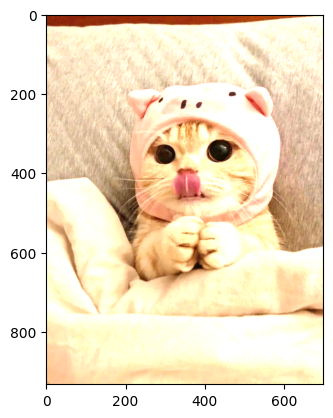

Características de la imagen cargada:
- Dimensiones: 933 x 700 x 3
- Tipo de datos: int64
- Peso en MB: 15.67
- Estadísticas por canal:
    - Min: (9, 0, 0)
    - Max: (255, 255, 255)
    - Mean: (241.71, 220.36, 186.08)
    - Std: (32.36, 51.01, 57.45)
    - Percentil 25: (250.00, 205.00, 163.00)
    - Percentil 50: (255.00, 243.00, 196.00)
    - Percentil 75: (255.00, 255.00, 228.00)

In [51]:
# Prueba: Multiplicación de un escalar a la imagen
gatito_mult = Imagen(np.clip((gatito * 1.8).imagen, 0, 255).astype(int))
gatito_mult.show()
gatito_mult

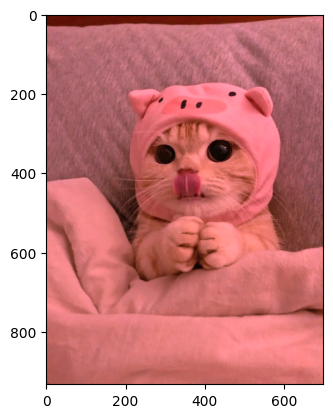

Características de la imagen cargada:
- Dimensiones: 933 x 700 x 3
- Tipo de datos: int64
- Peso en MB: 15.67
- Estadísticas por canal:
    - Min: (6, 0, 0)
    - Max: (255, 183, 221)
    - Mean: (193.56, 103.78, 104.31)
    - Std: (43.97, 28.14, 32.93)
    - Percentil 25: (166.00, 91.00, 91.00)
    - Percentil 50: (198.00, 108.00, 109.00)
    - Percentil 75: (228.00, 124.00, 127.00)

In [52]:
# Prueba: Multiplicación de un escalar a la imagen
gatito_mult = Imagen(np.clip((gatito * np.array([1.2, 0.8, 1.0])).imagen, 0, 255).astype(int))
gatito_mult.show()
gatito_mult

In [53]:
# Tests de sobrecarga de operadores.
# Importante - Saturación: Todos los elementos de la imagen deben ser a lo más 255.

# Test __add__
assert np.max((gatito + 1000).imagen) == 255
print("Test __add__ pasado")
# Test __radd__
assert np.max((1000 + gatito).imagen) == 255
print("Test __radd__ pasado")

# Test __sub__
assert np.min((gatito - (-1000)).imagen) == 255
print("Test __sub__ pasado")

# Test __sub__
assert np.max((gatito - 1000).imagen) == 0
print("Test __sub__ pasado")

# Test __rsub__
assert np.min((1000 - gatito).imagen) == 255
print("Test __rsub__ pasado")

# Test __mul__ (probar minimo)
assert np.max((-555555 * gatito).imagen) == 0
print("Test __mul__ pasado")

# Test __mul__ (probar maximo)
assert np.max((555555 * gatito).imagen) == 255
print("Test __mul__ pasado")

# Test __rmul__ (probar minimo)
assert np.max((gatito * -555555).imagen) == 0
print("Test __rmul__ pasado")

# Test __rmul__ (probar maximo)
assert np.max((gatito * 555555).imagen) == 255
print("Test __rmul__ pasado")

# Test que demuestra que __rsub__ no es lo mismo que __sub__ (resta no es conmutativa)
assert not np.array_equal((gatito - 50).imagen, (50 - gatito).imagen)
print("Test __rsub__ no es lo mismo que __sub__ pasado")

Test __add__ pasado
Test __radd__ pasado
Test __sub__ pasado
Test __sub__ pasado
Test __rsub__ pasado
Test __mul__ pasado
Test __mul__ pasado
Test __rmul__ pasado
Test __rmul__ pasado
Test __rsub__ no es lo mismo que __sub__ pasado


### 2.3 Clase de Procesamiento de Imágenes [2.5 puntos]

<div align="center">
    <img src="https://raw.githubusercontent.com/MDS7202/MDS7202/refs/heads/main/recursos/2026-01/labs/lab2/darkroom.jpg", width=400/>
</div>

Ahora que comprenden las diferentes dimensiones que componen a una imagen, realizaremos diferentes tareas de procesamiento de imágenes. 
Para esto, deben implementar los siguientes métodos de la clase "`LibImagen`":

- `to_negative` [0.2 puntos]: Pasar a negativo.
- `to_gray` [0.5 puntos]: Pasar una imagen a escala de grises.
- `get_channel` [0.5 puntos]: Obtener los canales R, G y B de forma individual.
- `flip` [0.5 puntos]: Rotar vertical u horizontalmente la imagen.
- `set_contrast` [0.5 puntos]: Modificar el contraste de una imagen.
- `conv_channel` [0 puntos, implementación provista]: Realizar una convolución sobre la imagen.

**Utilicen las fórmulas vistas al inicio del notebook y en el anexo para resolver esta sección.**

> **Nota 🗒️**: Al igual que en el ejercicio anterior, todo método debe tomar una `Imagen` y retornar una nueva `Imagen`. El resultado debe ser siempre un **nuevo objeto** que no modifique la imagen de entrada.

> **Nota 2 🗒️ — Tipos de datos:** El tipo de datos del arreglo resultante debe ser `int` (i.e., usar `.astype(int)`). Usar `uint8` puede causar desbordamiento silencioso (overflow): por ejemplo, `np.array([200], dtype='uint8') + 100` da `44` en lugar de `255`, porque `uint8` solo almacena valores entre 0 y 255 sin aviso. Con `int` el valor será `300`, lo que permite saturarlo correctamente con indexado condicional. Usar `float` tampoco es recomendable porque `plt.imshow` interpreta floats en el rango `[0.0, 1.0]`, por lo que los valores 0–255 aparecerían todos como blanco. Ver **Anexo A.4** para más detalles sobre tipos de datos en imágenes.

In [54]:
class LibImagen:
    def to_negative(self, img_in: Imagen) -> Imagen:
        """Convierte imagen a negativo.

        Parameters
        ----------
        img_in : Imagen
            Objeto Imagen que contiene imagen a procesar.

        Returns
        -------
        Imagen
            Objeto Imagen con la imagen procesada.
        """
        return 255 - img_in

    def to_gray(self, img_in: Imagen) -> Imagen:
        """
        Transforma una imagen en RGB a la escala de grises.

        Parameters
        ----------
        img_in : Imagen
            Objeto Imagen que contiene una imagen.

        Returns
        -------
        Imagen
            Una que contiene una imagen con 3 canales.
            Los 3 canales deben tener los mismos valores.
        """
        img = img_in.imagen
        imagen_gris = 0.299 * img[:, :, 0] + 0.587 * img[:, :, 1] + 0.114 * img[:, :, 2]
        imagen_gris = np.stack([imagen_gris, imagen_gris, imagen_gris], axis=2)
        return Imagen(imagen_gris.astype(int))

    def get_channel(self, img_in: Imagen, channel: str) -> Imagen:
        """Obtiene un canal de un color seteando el resto de los canales en 0.

        Levanta ValueError si el nombre del canal no es válido (no es 'r', 'g' o 'b').

        Parameters
        ----------
        img_in : Imagen
            Objeto Imagen que contiene una imagen.
        channel : str
            Nombre del canal que será seleccionado. Valores posibles: ('r','g' o 'b').

        Returns
        -------
        Imagen:
            Objeto Imagen que contiene una imagen con 3 canales.
            Solo el canal seleccionado debe tener valores distintos a 0.
        """
        if channel not in ["r", "g", "b"]:
            raise ValueError("El nombre del canal no es válido. Debe ser 'r', 'g' o 'b'.")

        idx = {"r": 0, "g": 1, "b": 2}[channel]
        new_img = np.zeros_like(img_in.imagen)
        new_img[:, :, idx] = img_in.imagen[:, :, idx]
        return Imagen(new_img)

    def flip(self, img_in: Imagen, axis: str) -> Imagen:
        """Voltea la imagen horizontal o verticalmente (ver anexo para indicaciones sobre slicing negativo).

        Lanza un ValueError si el valor de axis no es 'h' ni 'v'.

        Parameters
        ----------
        img_in : Imagen
            Objeto Imagen que contiene una imagen.
        axis : str
            Eje de volteo. Valores posibles: 'h' (horizontal) o 'v' (vertical).

        Returns
        -------
        Imagen
            Objeto Imagen con la imagen volteada.
        """
        if axis not in ["h", "v"]:
            raise ValueError("El valor de axis no es válido. Debe ser 'h' o 'v'.")

        if axis == "h":
            new_img = img_in.imagen[:, ::-1, :]
        elif axis == "v":
            new_img = img_in.imagen[::-1, :, :]

        return Imagen(np.copy(new_img))

    def set_saturation(self, img_in: Imagen, C: float) -> Imagen:
        """Fija la saturación de una imagen.

        Utiliza por debajo to_gray para calcular la escala de grises.

        Parameters
        ----------
        img_in : Imagen
            Objeto Imagen que contiene una imagen.
        C : float
            Parámetro que define el ajuste de saturación.

        Returns
        -------
        Imagen
            Objeto Imagen que contiene una imagen con 3 canales modificados.
        """
        img = img_in.imagen.astype(float)
        img_gray = self.to_gray(img_in).imagen.astype(float)

        resultado = img_gray + C * (img - img_gray)
        resultado[resultado > 255] = 255
        resultado[resultado < 0] = 0
        return Imagen(resultado.astype(int))

    def set_contrast(self, img_in: Imagen, C: float) -> Imagen:
        """Fija el contraste de una imagen.

        Parameters
        ----------
        img_in : Imagen
            Objeto Imagen que contiene una imagen.
        C : float
            Parámetro que define el ajuste de contraste.

        Returns
        -------
        Imagen
            Objeto Imagen que contiene una imagen con 3 canales modificados.
        """
        img = img_in.imagen.astype(float)
        F = 259 * (C + 255) / (255 * (259 - C))

        res = F * (img - 128) + 128
        res[res > 255] = 255
        res[res < 0] = 0
        return Imagen(res.astype(int))

    def conv_channel(self, img_in: Imagen, kernel: np.ndarray) -> Imagen:
        """Por documentar (esto es parte del puntaje)..."""
        img = img_in.imagen
        img_out = []
        for i in range(img.shape[-1]):
            img_channel = convolve2d(img[:, :, i], kernel, mode="same", boundary="symm")
            img_out.append(img_channel)
        new_image = np.stack(img_out, axis=2)
        new_image[new_image > 255], new_image[new_image < 0] = 255, 0
        return Imagen(new_image.astype(int))

### 2.4 Scripts para probar 

<div align="center">
    <img src="https://raw.githubusercontent.com/MDS7202/MDS7202/refs/heads/main/recursos/2026-01/labs/lab2/resultados_lib.png" alt="Resultados esperados">
</div>

Original


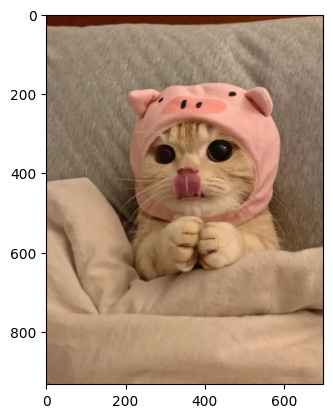

In [55]:
print("Original")
gatito = Imagen(images["gatitos"][1])
gatito.show()

In [56]:
# Recuerden recargar la librería cada vez que hagan cambios en ella para que el nuevo código se refleje en la ejecución
lib = LibImagen()

Negativo


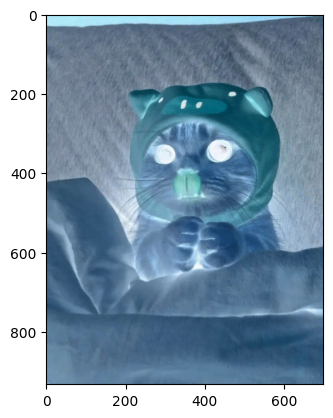

In [57]:
print("Negativo")
lib.to_negative(gatito).show()

Grayscale


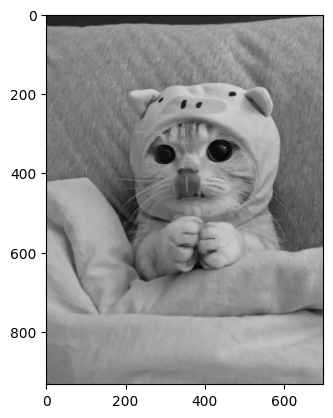

In [58]:
print("Grayscale")
lib.to_gray(gatito).show()

Selección de Canales


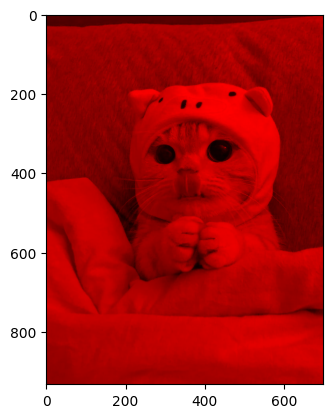

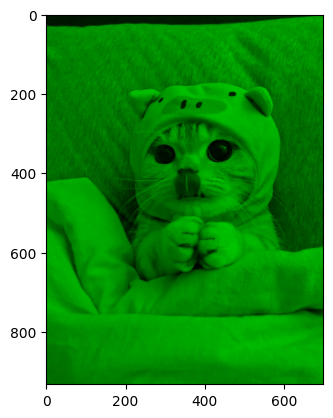

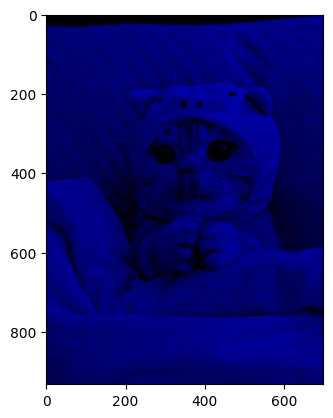

In [59]:
print("Selección de Canales")
lib.get_channel(gatito, "r").show()
lib.get_channel(gatito, "g").show()
lib.get_channel(gatito, "b").show()

Flip Horizontal


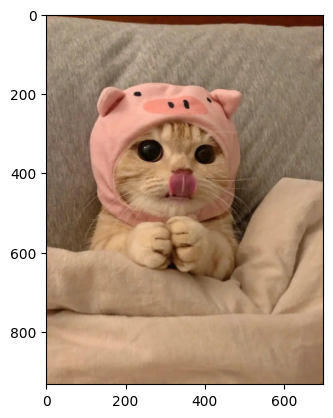

In [60]:
print("Flip Horizontal")
lib.flip(gatito, "h").show()

Flip Vertical


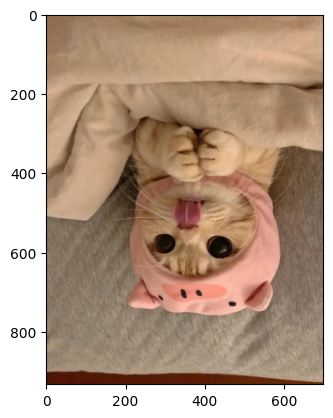

In [61]:
print("Flip Vertical")
lib.flip(img_in=gatito, axis="v").show()

Saturación C=2 (colores saturados)


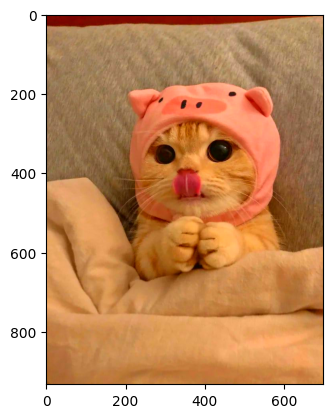

In [62]:
print("Saturación C=2 (colores saturados)")
lib.set_saturation(gatito, 2).show()

Mejora de Contraste


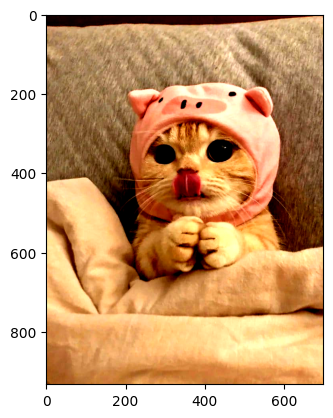

In [63]:
print("Mejora de Contraste")
lib.set_contrast(gatito, 100).show()

Convolución


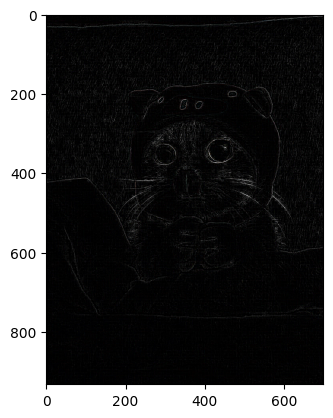

In [64]:
print("Convolución")
kernel = np.array(
    [
        [-1, -1, -1],
        [-1, 8, -1],
        [-1, -1, -1],
    ]
)

lib.conv_channel(gatito, kernel).show()

#### Implementar 5 Kernels y probarlos con las imágenes [0.5]

Referencia: 
https://en.wikipedia.org/wiki/Kernel_(image_processing)

In [65]:
# Convolución
kernel_1 = np.array([...])
kernel_2 = ...
kernel_3 = ...
kernel_4 = ...
kernel_5 = ...

lib.conv_channel(gatito, kernel_1).show()

ValueError: convolve2d inputs must both be 2-D arrays

**Comenten:**

Para finalizar, comenten qué hace (o debería hacer) cada filtro convolucional al aplicarlas a su imagen de ejemplo.

```
(Escriba aquí su justificación)

El filtro...

1.- 
2.-
3.- 
4.- 
5.-
```

# Conclusión

Eso ha sido todo para el lab de hoy. Recuerden, cualquier duda del laboratorio, no duden en contactarnos por mail o U-cursos.

<div style="text-align: center;">
    <img src="https://media.giphy.com/media/5xtDaroSIXzLa6dvfI4/giphy.gif" alt="Gracias Totales!">
</div>


---

# Anexo


## A.1 Copia vs. Referencia en NumPy

Uno de los errores más frecuentes al trabajar con NumPy es confundir una **referencia** con una **copia**.

### Referencia: `a = b`

```python
a = np.array([1, 2, 3])
b = a          # b NO es una copia, es el mismo objeto en memoria
b[0] = 999
print(a)       # [999, 2, 3]  ← ¡a también cambió!
```

Cuando hacemos `b = a`, tanto `b` como `a` apuntan al **mismo arreglo en memoria**. Modificar uno modifica al otro.

### Copia: `a = b.copy()` o `np.copy(b)`

```python
a = np.array([1, 2, 3])
b = a.copy()   # b es un arreglo independiente
b[0] = 999
print(a)       # [1, 2, 3]  ← a no cambió
```

### Vistas (slicing)

El slicing en NumPy también devuelve una **vista**, no una copia:

```python
a = np.array([1, 2, 3, 4, 5])
b = a[1:3]     # b es una vista de a
b[0] = 999
print(a)       # [1, 999, 3, 4, 5]
```

Para crear una copia explícita de un slice, usa `a[1:3].copy()`.

### ¿Por qué importa esto en la clase `Imagen`?

Cuando implementen métodos como `__add__`, deben asegurarse de retornar un nuevo objeto `Imagen` con una **copia** del array resultante, no una referencia al array interno de `self`. De lo contrario, operaciones posteriores podrían modificar la imagen original sin que el usuario se dé cuenta.

```python
# ❌ Incorrecto: retorna referencia al array interno
def __add__(self, other):
    ...
    return Imagen(result) 

# ✅ Correcto: retorna copia explícita
def __add__(self, other):
    ...
    return Imagen(np.copy(result).astype(int))
```


## A.2 Métodos Mágicos (Dunder Methods)

En Python, los **métodos mágicos** (también llamados *dunder methods* por sus dobles guiones bajos `__`) son métodos especiales que Python llama automáticamente en respuesta a ciertas operaciones. No están pensados para llamarse directamente, sino para ser invocados por el intérprete.

### Tabla de métodos mágicos comunes

| Método | Cuándo se llama | Ejemplo |
|---|---|---|
| `__init__(self, ...)` | Al crear un objeto | `img = Imagen(array)` |
| `__repr__(self)` | Al representar el objeto | `repr(img)` / `img` en notebook |
| `__str__(self)` | Al convertir a string | `str(img)` / `print(img)` |
| `__len__(self)` | Al pedir la longitud | `len(img)` |
| `__getitem__(self, key)` | Al indexar | `img[0]` |
| `__add__(self, other)` | `self + other` | `img + 50` |
| `__radd__(self, other)` | `other + self` (cuando `other` no sabe sumar con `self`) | `50 + img` |
| `__sub__(self, other)` | `self - other` | `img - 50` |
| `__rsub__(self, other)` | `other - self` | `50 - img` |
| `__mul__(self, other)` | `self * other` | `img * 2` |
| `__rmul__(self, other)` | `other * self` | `2 * img` |
| `__eq__(self, other)` | `self == other` | `img1 == img2` |

### `__add__` vs `__radd__`: ¿cuándo llama Python a cada uno?

Cuando Python evalúa `a + b`:
1. Primero intenta `a.__add__(b)`.
2. Si `a.__add__(b)` retorna `NotImplemented` (o el método no existe), entonces intenta `b.__radd__(a)`.

Esto permite que nuestros objetos sean compatibles con operaciones donde la instancia va a la derecha:

```python
50 + img   # Python intenta int.__add__(img) → falla → llama img.__radd__(50)
```

Por eso, para que tanto `img + 50` como `50 + img` funcionen, necesitamos implementar **ambos** métodos. En los casos donde la operación es conmutativa (suma, multiplicación), `__radd__` simplemente puede llamar a `__add__`:

```python
def __radd__(self, other):
    return self.__add__(other)  # o simplemente: return self + other
```

Para la resta (`__rsub__`), **no son intercambiables** porque la resta NO es conmutativa:

```python
img - 50   # llama img.__sub__(50)    → img.imagen - 50
50 - img   # llama img.__rsub__(50)   → 50 - img.imagen  (¡distinto!)
```

### `__repr__` y `__str__`

- `__repr__`: representación **oficial** del objeto, idealmente una expresión que permita recrearlo. En Jupyter, es lo que se muestra al evaluar una variable en una celda.
- `__str__`: representación **informal** pensada para el usuario. Es la que usa `print()`.
- Si solo defines `__repr__`, Python usará ese también para `__str__`.

```python
class Punto:
    def __init__(self, x, y):
        self.x, self.y = x, y

    def __repr__(self):
        return f"Punto(x={self.x}, y={self.y})"

p = Punto(3, 4)
print(p)     # Punto(x=3, y=4)
repr(p)      # 'Punto(x=3, y=4)'
```


## A.3 `np.clip` y saturación de valores

`np.clip(a, a_min, a_max)` es la función de NumPy para **saturar** (clampear) los valores de un arreglo a un rango determinado. Cualquier valor menor que `a_min` se convierte en `a_min`; cualquier valor mayor que `a_max` se convierte en `a_max`.

```python
a = np.array([-50, 0, 100, 200, 300])
np.clip(a, 0, 255)
# array([  0,   0, 100, 200, 255])
```

En el contexto de imágenes, sería el equivalente a:

```python
imagen_resultado = np.clip(imagen + 50, 0, 255)
```

### ¿Por qué no lo usamos en este lab?

En este laboratorio, la saturación debe implementarse usando **indexado condicional**, lo cual es un patrón fundamental en NumPy y pandas:

```python
result = imagen + 50
result[result > 255] = 255
result[result < 0]   = 0
```

Esto es funcionalmente equivalente a `np.clip`, pero practicar el indexado condicional es uno de los objetivos del laboratorio. `np.clip` es la herramienta idiomática y preferida en producción.


## A.4 Tipos de datos en imágenes NumPy

La elección del tipo de datos (`dtype`) de un arreglo NumPy tiene consecuencias importantes en el procesamiento de imágenes.

| `dtype` | Rango | Comportamiento en `plt.imshow` | Recomendado para... |
|---|---|---|---|
| `uint8` | 0–255 | Correcto (rango 0–255) | Almacenamiento final, exportar imágenes |
| `int` / `int64` | −2³¹ a 2³¹ | Correcto (rango 0–255) | Procesamiento intermedio |
| `float32/64` | cualquier real | Interpreta rango **[0.0, 1.0]** | Redes neuronales, operaciones en punto flotante |

### El problema con `uint8`: overflow silencioso

`uint8` solo puede almacenar valores entre 0 y 255. Si el resultado de una operación excede ese rango, **desborda silenciosamente** (sin error ni advertencia):

```python
a = np.array([200], dtype='uint8')
a + 100
# array([44], dtype=uint8)   ← ¡44, no 255!
# 200 + 100 = 300, y 300 % 256 = 44
```

Por eso, para procesar imágenes con operaciones aritméticas, conviene trabajar con `int` y saturar manualmente. Solo al final, si es necesario exportar la imagen, se convierte a `uint8`.

### El problema con `float`: escala incorrecta

`plt.imshow` tiene dos comportamientos distintos según el tipo:
- Array `int`: espera valores en el rango **[0, 255]**. Valores fuera de ese rango se clampean.
- Array `float`: espera valores en el rango **[0.0, 1.0]**. Si pasas valores 0–255 como float, la imagen aparecerá **completamente blanca** (todos los valores se interpretan como ≥ 1.0).

```python
# ❌ Incorrecto: imagen toda blanca
plt.imshow(imagen.astype(float))

# ✅ Correcto: mantener como int o normalizar a [0, 1]
plt.imshow(imagen.astype(int))
plt.imshow(imagen.astype(float) / 255.0)
```


## A.5 Slicing con paso negativo en NumPy

En NumPy (y en Python en general), la sintaxis de slicing permite especificar un **paso** (*step*) como tercer argumento: `array[inicio:fin:paso]`. Cuando el paso es `-1`, se recorre el eje en orden inverso, lo que equivale a **invertir** ese eje.

### Sintaxis básica

```python
a = np.array([1, 2, 3, 4, 5])
a[::-1]       # array([5, 4, 3, 2, 1])   ← orden invertido
a[::2]        # array([1, 3, 5])          ← un elemento de cada 2
a[1:4]        # array([2, 3, 4])          ← de índice 1 a 3
```

### Referencias lab 2

- http://www.cs.cornell.edu/cv/SummerSchool/Introduction.pdf
- https://en.wikipedia.org/wiki/Tensor
- https://support.ptc.com/help/mathcad/es/index.html#page/PTC_Mathcad_Help/example_grayscale_and_color_in_images.html
- http://w3.unpocodetodo.info/canvas/negativo.php
- http://www.dfstudios.co.uk/articles/programming/image-programming-algorithms/image-processing-algorithms-part-5-contrast-adjustment/

<br>
<center>
<img src="https://i.kym-cdn.com/photos/images/original/001/194/195/b18.png" width=100 height=50 />
</center>
<br>